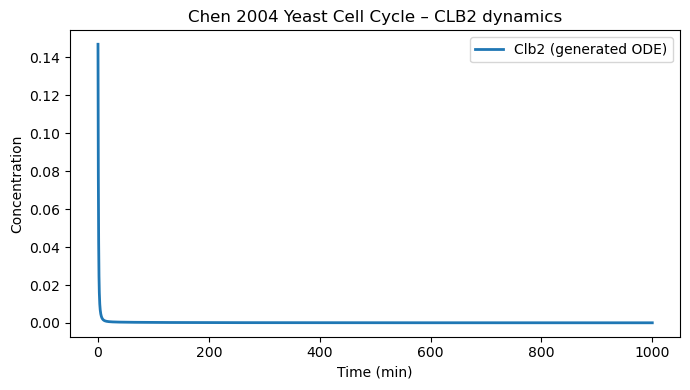

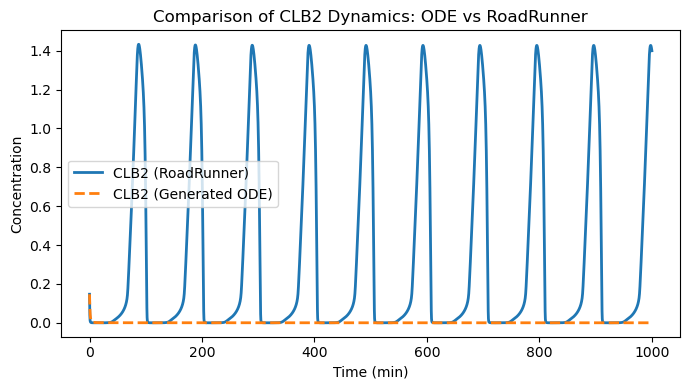

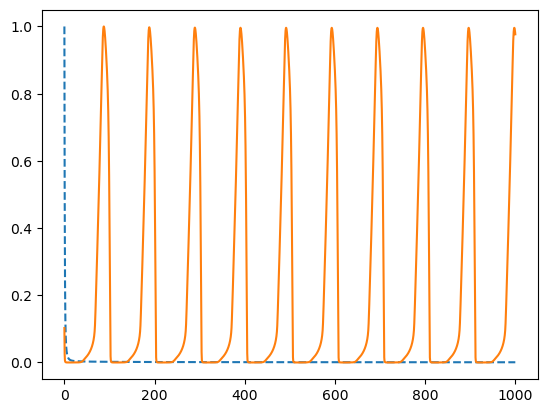

In [1]:
from numpy import *
from matplotlib.pylab import *
from matplotlib.pyplot import *
from scipy.integrate import odeint

def simulateModel(t0, tend, numPoints):
  # compartments
  cell = 1.0

  # global parameters
  b0 = 0.054
  bub2h = 1.0
  bub2l = 0.2
  C0 = 0.4
  CDC15T = 1.0
  Dn3 = 1.0
  ebudb5 = 1.0
  ebudn2 = 0.25
  ebudn3 = 0.05
  ec1b2 = 0.45
  ec1b5 = 0.1
  ec1k2 = 0.03
  ec1n2 = 0.06
  ec1n3 = 0.3
  ef6b2 = 0.55
  ef6b5 = 0.1
  ef6k2 = 0.03
  ef6n2 = 0.06
  ef6n3 = 0.3
  eicdhb2 = 1.2
  eicdhb5 = 8.0
  eicdhn2 = 0.4
  eicdhn3 = 0.25
  eorib2 = 0.45
  eorib5 = 0.9
  esbfb5 = 2.0
  esbfn2 = 2.0
  esbfn3 = 10.0
  ESP1T = 1.0
  IET = 1.0
  J20ppx = 0.15
  Jacdh = 0.03
  Jaiep = 0.1
  Jamcm = 0.1
  Jasbf = 0.01
  Jatem = 0.1
  Jd2c1 = 0.05
  Jd2f6 = 0.05
  Jicdh = 0.03
  Jiiep = 0.1
  Jimcm = 0.1
  Jisbf = 0.01
  Jitem = 0.1
  Jn3 = 6.0
  Jpds = 0.04
  Jspn = 0.14
  ka15_p = 0.002
  ka15_p_p = 1.0
  ka15p = 0.001
  ka20_p = 0.05
  ka20_p_p = 0.2
  kacdh_p = 0.01
  kacdh_p_p = 0.8
  kaiep = 0.1
  kamcm = 1.0
  kasb2 = 50.0
  kasb5 = 50.0
  kasbf = 0.38
  kasesp = 50.0
  kasf2 = 15.0
  kasf5 = 0.01
  kasrent = 200.0
  kasrentp = 1.0
  kaswi = 2.0
  kd14 = 0.1
  kd1c1 = 0.01
  kd1f6 = 0.01
  kd1pds_p = 0.01
  kd20 = 0.3
  kd2c1 = 1.0
  kd2f6 = 1.0
  kd2pds_p_p = 0.2
  kd3c1 = 1.0
  kd3f6 = 1.0
  kd3pds_p_p = 0.04
  kdb2_p = 0.003
  kdb2_p_p = 0.4
  kdb2p = 0.15
  kdb5_p = 0.01
  kdb5_p_p = 0.16
  kdbud = 0.06
  kdcdh = 0.01
  kdib2 = 0.05
  kdib5 = 0.06
  kdiesp = 0.5
  kdif2 = 0.5
  kdif5 = 0.01
  kdirent = 1.0
  kdirentp = 2.0
  kdn2 = 0.12
  kdnet = 0.03
  kdori = 0.06
  kdppx_p = 0.17
  kdppx_p_p = 2.0
  kdspn = 0.06
  kdswi = 0.08
  KEZ = 0.3
  KEZ2 = 0.2
  ki15 = 0.5
  kicdh_p = 0.001
  kicdh_p_p = 0.08
  kiiep = 0.15
  kimcm = 0.15
  kisbf_p = 0.6
  kisbf_p_p = 8.0
  kiswi = 0.05
  kkpnet_p = 0.01
  kkpnet_p_p = 0.6
  kppc1 = 4.0
  kppf6 = 4.0
  kppnet_p = 0.05
  kppnet_p_p = 3.0
  ks14 = 0.2
  ks1pds_p_p = 0.03
  ks20_p = 0.006
  ks20_p_p = 0.6
  ks2pds_p_p = 0.055
  ksb2_p = 0.001
  ksb2_p_p = 0.04
  ksb5_p = 0.0008
  ksb5_p_p = 0.005
  ksbud = 0.2
  ksc1_p = 0.012
  ksc1_p_p = 0.12
  kscdh = 0.01
  ksf6_p = 0.024
  ksf6_p_p = 0.12
  ksf6_p_p_p = 0.004
  ksn2_p = 0.0
  ksn2_p_p = 0.15
  ksnet = 0.084
  ksori = 2.0
  kspds_p = 0.0
  ksppx = 0.1
  ksspn = 0.1
  ksswi_p = 0.005
  ksswi_p_p = 0.08
  lte1h = 1.0
  lte1l = 0.1
  mad2h = 8.0
  mad2l = 0.01
  mdt = 90.0
  TEM1T = 1.0
  D = 0.0
  mu = 0.0
  Vdb5 = 0.0
  Vdb2 = 0.0
  Vasbf = 0.0
  Visbf = 0.0
  Vkpc1 = 0.0
  Vkpf6 = 0.0
  Vacdh = 0.0
  Vicdh = 0.0
  Vppnet = 0.0
  Vkpnet = 0.0
  Vdppx = 0.0
  Vdpds = 0.0
  Vaiep = 0.0
  Vd2c1 = 0.0
  Vd2f6 = 0.0
  Vppc1 = 0.0
  Vppf6 = 0.0
  F = 0.0
  Inactivation_2_k = 1.0

  # boundary species
  CDC15i = 0.0
  IE = 0.0
  PE = 0.0
  TEM1GDP = 0.0

  def ode_fun(__Y__, t):
    BCK2 = __Y__[0]
    BUB2 = __Y__[1]
    BUD = __Y__[2]
    C2 = __Y__[3]
    C2P = __Y__[4]
    C5 = __Y__[5]
    C5P = __Y__[6]
    CDC14 = __Y__[7]
    CDC14T = __Y__[8]
    CDC15 = __Y__[9]
    CDC20 = __Y__[10]
    CDC20i = __Y__[11]
    CDC6 = __Y__[12]
    CDC6P = __Y__[13]
    CDC6T = __Y__[14]
    CDH1 = __Y__[15]
    CDH1i = __Y__[16]
    CKIT = __Y__[17]
    CLB2 = __Y__[18]
    CLB2T = __Y__[19]
    CLB5 = __Y__[20]
    CLB5T = __Y__[21]
    CLN2 = __Y__[22]
    CLN3 = __Y__[23]
    ESP1 = __Y__[24]
    F2 = __Y__[25]
    F2P = __Y__[26]
    F5 = __Y__[27]
    F5P = __Y__[28]
    IEP = __Y__[29]
    LTE1 = __Y__[30]
    MAD2 = __Y__[31]
    MASS = __Y__[32]
    MCM1 = __Y__[33]
    NET1 = __Y__[34]
    NET1P = __Y__[35]
    NET1T = __Y__[36]
    ORI = __Y__[37]
    PDS1 = __Y__[38]
    PPX = __Y__[39]
    RENT = __Y__[40]
    RENTP = __Y__[41]
    SBF = __Y__[42]
    SIC1 = __Y__[43]
    SIC1P = __Y__[44]
    SIC1T = __Y__[45]
    SPN = __Y__[46]
    SWI5 = __Y__[47]
    SWI5P = __Y__[48]
    TEM1GTP = __Y__[49]

    Growth = mu * MASS
    Synthesis_of_CLN2 = (ksn2_p + ksn2_p_p * SBF) * MASS
    Degradation_of_CLN2 = kdn2 * CLN2
    Synthesis_of_CLB2 = (ksb2_p + ksb2_p_p * MCM1) * MASS
    Degradation_of_CLB2 = Vdb2 * CLB2
    Synthesis_of_CLB5 = (ksb5_p + ksb5_p_p * SBF) * MASS
    Degradation_of_CLB5 = Vdb5 * CLB5
    Synthesis_of_SIC1 = ksc1_p + ksc1_p_p * SWI5
    Phosphorylation_of_SIC1 = Vkpc1 * SIC1
    Dephosphorylation_of_SIC1 = Vppc1 * SIC1P
    Fast_Degradation_of_SIC1P = kd3c1 * SIC1P
    Assoc_of_CLB2_and_SIC1 = kasb2 * CLB2 * SIC1
    Dissoc_of_CLB2SIC1_complex = kdib2 * C2
    Assoc_of_CLB5_and_SIC1 = kasb5 * CLB5 * SIC1
    Dissoc_of_CLB5SIC1 = kdib5 * C5
    Phosphorylation_of_C2 = Vkpc1 * C2
    Dephosphorylation_of_C2P = Vppc1 * C2P
    Phosphorylation_of_C5 = Vkpc1 * C5
    Dephosphorylation_of_C5P = Vppc1 * C5P
    Degradation_of_CLB2_in_C2 = Vdb2 * C2
    Degradation_of_CLB5_in_C5 = Vdb5 * C5
    Degradation_of_SIC1_in_C2P = kd3c1 * C2P
    Degradation_of_SIC1P_in_C5P_ = kd3c1 * C5P
    Degradation_of_CLB2_in_C2P = Vdb2 * C2P
    Degradation_of_CLB5_in_C5P = Vdb5 * C5P
    CDC6_synthesis = ksf6_p + ksf6_p_p * SWI5 + ksf6_p_p_p * SBF
    Phosphorylation_of_CDC6 = Vkpf6 * CDC6
    Dephosphorylation_of_CDC6 = Vppf6 * CDC6P
    Degradation_of_CDC6P = kd3f6 * CDC6P
    CLB2CDC6_complex_formation = kasf2 * CLB2 * CDC6
    CLB2CDC6_dissociation = kdif2 * F2
    CLB5CDC6_complex_formation = kasf5 * CLB5 * CDC6
    CLB5CDC6_dissociation = kdif5 * F5
    F2_phosphorylation = Vkpf6 * F2
    F2P_dephosphorylation = Vppf6 * F2P
    F5_phosphorylation = Vkpf6 * F5
    F5P_dephosphorylation = Vppf6 * F5P
    CLB2_degradation_in_F2 = Vdb2 * F2
    CLB5_degradation_in_F5 = Vdb5 * F5
    CDC6_degradation_in_F2P = kd3f6 * F2P
    CDC6_degradation_in_F5P = kd3f6 * F5P
    CLB2_degradation_in_F2P = Vdb2 * F2P
    CLB5_degradation_in_F5P = Vdb5 * F5P
    Synthesis_of_SWI5 = ksswi_p + ksswi_p_p * MCM1
    Degradation_of_SWI5 = kdswi * SWI5
    Degradation_of_SWI5P = kdswi * SWI5P
    Activation_of_SWI5 = kaswi * CDC14 * SWI5P
    Inactivation_of_SWI5 = kiswi * CLB2 * SWI5
    Activation_of_IEP = 1 * IE * Vaiep / (Jaiep + IE)
    Inactivation_1 = kiiep * IEP * 1 / (Jiiep + IEP)
    Synthesis_of_inactive_CDC20 = ks20_p + ks20_p_p * MCM1
    Degradation_of_inactiveCDC20 = kd20 * CDC20i
    Degradation_of_active_CDC20 = kd20 * CDC20
    Activation_of_CDC20 = (ka20_p + ka20_p_p * IEP) * CDC20i
    Inactivation_2 = Inactivation_2_k * MAD2 * CDC20
    CDH1_synthesis = kscdh
    CDH1_degradation = kdcdh * CDH1
    CDH1i_degradation = kdcdh * CDH1i
    CDH1i_activation = 1 * CDH1i * Vacdh / (Jacdh + CDH1i)
    Inactivation_3 = 1 * CDH1 * Vicdh / (Jicdh + CDH1)
    CDC14_synthesis = ks14
    CDC14_degradation = kd14 * CDC14
    Assoc_with_NET1_to_form_RENT = kasrent * CDC14 * NET1
    Dissoc_from_RENT = kdirent * RENT
    Assoc_with_NET1P_to_form_RENTP = kasrentp * CDC14 * NET1P
    Dissoc_from_RENP = kdirentp * RENTP
    Net1_synthesis = ksnet
    Net1_degradation = kdnet * NET1
    Net1P_degradation = kdnet * NET1P
    NET1_phosphorylation = Vkpnet * NET1
    dephosphorylation_1 = Vppnet * NET1P
    RENT_phosphorylation = Vkpnet * RENT
    dephosphorylation_2 = Vppnet * RENTP
    Degradation_of_NET1_in_RENT = kdnet * RENT
    Degradation_of_NET1P_in_RENTP = kdnet * RENTP
    Degradation_of_CDC14_in_RENT = kd14 * RENT
    Degradation_of_CDC14_in_RENTP = kd14 * RENTP
    TEM1_activation = 1 * TEM1GDP * LTE1 / (Jatem + TEM1GDP)
    inactivation_1 = 1 * TEM1GTP * BUB2 / (Jitem + TEM1GTP)
    CDC15_activation = (ka15_p * TEM1GDP + ka15_p_p * TEM1GTP + ka15p * CDC14) * CDC15i
    inactivation_2 = ki15 * CDC15
    PPX_synthesis = ksppx
    degradation_1 = Vdppx * PPX
    PDS1_synthesis = kspds_p + ks1pds_p_p * SBF + ks2pds_p_p * MCM1
    degradation_2 = Vdpds * PDS1
    Degradation_of_PDS1_in_PE = Vdpds * PE
    Assoc_with_ESP1_to_form_PE = kasesp * PDS1 * ESP1
    Disso_from_PE = kdiesp * PE
    DNA_synthesis = ksori * (eorib5 * CLB5 + eorib2 * CLB2)
    Negative_regulation_of_DNA_synthesis = kdori * ORI
    Budding = ksbud * (ebudn2 * CLN2 + ebudn3 * CLN3 + ebudb5 * CLB5)
    Negative_regulation_of_Cell_budding = kdbud * BUD
    Spindle_formation = ksspn * CLB2 / (Jspn + CLB2)
    Spindle_disassembly = kdspn * SPN

    return array([
      (0),

      (0),

      (Budding + -Negative_regulation_of_Cell_budding),

      (Assoc_of_CLB2_and_SIC1 + -Dissoc_of_CLB2SIC1_complex + -Phosphorylation_of_C2 + Dephosphorylation_of_C2P + -Degradation_of_CLB2_in_C2),

      (Phosphorylation_of_C2 + -Dephosphorylation_of_C2P + -Degradation_of_SIC1_in_C2P + -Degradation_of_CLB2_in_C2P),

      (Assoc_of_CLB5_and_SIC1 + -Dissoc_of_CLB5SIC1 + -Phosphorylation_of_C5 + Dephosphorylation_of_C5P + -Degradation_of_CLB5_in_C5),

      (Phosphorylation_of_C5 + -Dephosphorylation_of_C5P + -Degradation_of_SIC1P_in_C5P_ + -Degradation_of_CLB5_in_C5P),

      (CDC14_synthesis + -CDC14_degradation + -Assoc_with_NET1_to_form_RENT + Dissoc_from_RENT + -Assoc_with_NET1P_to_form_RENTP + Dissoc_from_RENP + Degradation_of_NET1_in_RENT + Degradation_of_NET1P_in_RENTP),

      (0),

      (CDC15_activation + -inactivation_2),

      (-Degradation_of_active_CDC20 + Activation_of_CDC20 + -Inactivation_2),

      (Synthesis_of_inactive_CDC20 + -Degradation_of_inactiveCDC20 + -Activation_of_CDC20 + Inactivation_2),

      (CDC6_synthesis + -Phosphorylation_of_CDC6 + Dephosphorylation_of_CDC6 + -CLB2CDC6_complex_formation + CLB2CDC6_dissociation + -CLB5CDC6_complex_formation + CLB5CDC6_dissociation + CLB2_degradation_in_F2 + CLB5_degradation_in_F5),

      (Phosphorylation_of_CDC6 + -Dephosphorylation_of_CDC6 + -Degradation_of_CDC6P + CLB2_degradation_in_F2P + CLB5_degradation_in_F5P),

      (0),

      (CDH1_synthesis + -CDH1_degradation + CDH1i_activation + -Inactivation_3),

      (-CDH1i_degradation + -CDH1i_activation + Inactivation_3),

      (0),

      (Synthesis_of_CLB2 + -Degradation_of_CLB2 + -Assoc_of_CLB2_and_SIC1 + Dissoc_of_CLB2SIC1_complex + Degradation_of_SIC1_in_C2P + -CLB2CDC6_complex_formation + CLB2CDC6_dissociation + CDC6_degradation_in_F2P),

      (0),

      (Synthesis_of_CLB5 + -Degradation_of_CLB5 + -Assoc_of_CLB5_and_SIC1 + Dissoc_of_CLB5SIC1 + Degradation_of_SIC1P_in_C5P_ + -CLB5CDC6_complex_formation + CLB5CDC6_dissociation + CDC6_degradation_in_F5P),

      (0),

      (Synthesis_of_CLN2 + -Degradation_of_CLN2),

      (0),

      (Degradation_of_PDS1_in_PE + -Assoc_with_ESP1_to_form_PE + Disso_from_PE),

      (CLB2CDC6_complex_formation + -CLB2CDC6_dissociation + -F2_phosphorylation + F2P_dephosphorylation + -CLB2_degradation_in_F2),

      (F2_phosphorylation + -F2P_dephosphorylation + -CDC6_degradation_in_F2P + -CLB2_degradation_in_F2P),

      (CLB5CDC6_complex_formation + -CLB5CDC6_dissociation + -F5_phosphorylation + F5P_dephosphorylation + -CLB5_degradation_in_F5),

      (F5_phosphorylation + -F5P_dephosphorylation + -CDC6_degradation_in_F5P + -CLB5_degradation_in_F5P),

      (Activation_of_IEP + -Inactivation_1),

      (0),

      (0),

      (Growth),

      (0),

      (-Assoc_with_NET1_to_form_RENT + Dissoc_from_RENT + Net1_synthesis + -Net1_degradation + -NET1_phosphorylation + dephosphorylation_1 + Degradation_of_CDC14_in_RENT),

      (-Assoc_with_NET1P_to_form_RENTP + Dissoc_from_RENP + -Net1P_degradation + NET1_phosphorylation + -dephosphorylation_1 + Degradation_of_CDC14_in_RENTP),

      (0),

      (DNA_synthesis + -Negative_regulation_of_DNA_synthesis),

      (PDS1_synthesis + -degradation_2 + -Assoc_with_ESP1_to_form_PE + Disso_from_PE),

      (PPX_synthesis + -degradation_1),

      (Assoc_with_NET1_to_form_RENT + -Dissoc_from_RENT + -RENT_phosphorylation + dephosphorylation_2 + -Degradation_of_NET1_in_RENT + -Degradation_of_CDC14_in_RENT),

      (Assoc_with_NET1P_to_form_RENTP + -Dissoc_from_RENP + RENT_phosphorylation + -dephosphorylation_2 + -Degradation_of_NET1P_in_RENTP + -Degradation_of_CDC14_in_RENTP),

      (0),

      (Synthesis_of_SIC1 + -Phosphorylation_of_SIC1 + Dephosphorylation_of_SIC1 + -Assoc_of_CLB2_and_SIC1 + Dissoc_of_CLB2SIC1_complex + -Assoc_of_CLB5_and_SIC1 + Dissoc_of_CLB5SIC1 + Degradation_of_CLB2_in_C2 + Degradation_of_CLB5_in_C5),

      (Phosphorylation_of_SIC1 + -Dephosphorylation_of_SIC1 + -Fast_Degradation_of_SIC1P + Degradation_of_CLB2_in_C2P + Degradation_of_CLB5_in_C5P),

      (0),

      (Spindle_formation + -Spindle_disassembly),

      (Synthesis_of_SWI5 + -Degradation_of_SWI5 + Activation_of_SWI5 + -Inactivation_of_SWI5),

      (-Degradation_of_SWI5P + -Activation_of_SWI5 + Inactivation_of_SWI5),

      (TEM1_activation + -inactivation_1)
    ])

  time = linspace(t0, tend, numPoints)
  yinit = array([
    0.0,

    0.2,

    0.008473,

    0.238404,

    0.024034,

    0.070081,

    0.006878,

    0.468344,

    2.0,

    0.656533,

    0.444296,

    1.472044,

    0.10758,

    0.015486,

    0.0,

    0.930499,

    0.0695,

    0.0,

    0.1469227,

    0.17,

    0.0518014,

    0.12,

    0.0652511,

    0.0,

    0.301313,

    0.236058,

    0.0273938,

    7.24e-05,

    7.91e-05,

    0.1015,

    0.1,

    0.01,

    1.206019,

    0.0,

    0.018645,

    0.970271,

    2.8,

    0.000909,

    0.025612,

    0.123179,

    1.04954,

    0.6,

    0.0,

    0.0228776,

    0.00641,

    0.0,

    0.03,

    0.95,

    0.02,

    0.9
  ])

  y = odeint(ode_fun, yinit, time)

  return time, y


time, result = simulateModel(0, 1000, 5000)
import matplotlib.pyplot as plt

time, result = simulateModel(0, 1000, 5000)

plt.figure(figsize=(7, 4))
plt.plot(time, result[:, 18], label='Clb2 (generated ODE)', lw=2)
plt.xlabel('Time (min)')
plt.ylabel('Concentration')
plt.legend()
plt.title('Chen 2004 Yeast Cell Cycle – CLB2 dynamics')
plt.tight_layout()
plt.show()

import tellurium as te
import matplotlib.pyplot as plt

# Load and simulate SBML directly with RoadRunner
rr = te.loadSBMLModel("chen_model.xml")
rr_result = rr.simulate(0, 1000, 5000)

# Plot comparison
plt.figure(figsize=(7,4))
plt.plot(rr_result[:,0], rr_result[:, rr.model.getFloatingSpeciesIds().index("CLB2")+1],
         label='CLB2 (RoadRunner)', lw=2)
plt.plot(time, result[:,18], '--', label='CLB2 (Generated ODE)', lw=2)
plt.xlabel('Time (min)')
plt.ylabel('Concentration')
plt.legend()
plt.title('Comparison of CLB2 Dynamics: ODE vs RoadRunner')
plt.tight_layout()
plt.show()

plt.plot(time, result[:,18]/max(result[:,18]), '--', label='ODE normalized')
plt.plot(rr_result[:,0], rr_result[:,rr.model.getFloatingSpeciesIds().index("CLB2")+1]/
         max(rr_result[:,rr.model.getFloatingSpeciesIds().index("CLB2")+1]), 
         label='RR normalized')


# GPU-Accelerated Chen Yeast Model Simulation

This notebook implements the Chen 2004 budding yeast cell cycle model with GPU acceleration for AMD Radeon RX 470/480.

**GPU Acceleration Methods:**
- PyTorch with ROCm (AMD GPU support)
- OpenCL fallback
- Automatic GPU detection and optimization

**Performance Benefits:**
- Parallel ODE solving on GPU
- Batch parameter sampling
- Vectorized complexity calculations
- Memory-optimized operations

In [6]:
import tellurium as te
import libsbml

# Load the SBML model into RoadRunner
rr = te.loadSBMLModel("chen_model.xml")

# Extract the SBML string and re-parse it with libSBML
sbml_str = rr.getSBML()
doc = libsbml.readSBMLFromString(sbml_str)
model = doc.getModel()


# --- Print all reactions and their rate laws ---
print("=== Reactions ===")
for i in range(model.getNumReactions()):
    reaction = model.getReaction(i)
    rate_law = reaction.getKineticLaw()
    formula = rate_law.getFormula() if rate_law else "No kinetic law"
    print(f"{reaction.getId()}: {formula}")

# --- Print all assignment rules ---
print("\n=== Assignment rules ===")
for i in range(model.getNumRules()):
    rule = model.getRule(i)
    if rule.isAssignment():
        print(f"{rule.getVariable()} = {rule.getFormula()}")


=== Reactions ===
Growth: mu * MASS
Synthesis_of_CLN2: (ksn2_p + ksn2_p_p * SBF) * MASS
Degradation_of_CLN2: Mass_Action_1_222(kdn2, CLN2)
Synthesis_of_CLB2: (ksb2_p + ksb2_p_p * MCM1) * MASS
Degradation_of_CLB2: Mass_Action_1_222(Vdb2, CLB2)
Synthesis_of_CLB5: (ksb5_p + ksb5_p_p * SBF) * MASS
Degradation_of_CLB5: Mass_Action_1_222(Vdb5, CLB5)
Synthesis_of_SIC1: ksc1_p + ksc1_p_p * SWI5
Phosphorylation_of_SIC1: Mass_Action_1_222(Vkpc1, SIC1)
Dephosphorylation_of_SIC1: Mass_Action_1_222(Vppc1, SIC1P)
Fast_Degradation_of_SIC1P: Mass_Action_1_222(kd3c1, SIC1P)
Assoc_of_CLB2_and_SIC1: Mass_Action_2_221(kasb2, CLB2, SIC1)
Dissoc_of_CLB2SIC1_complex: Mass_Action_1_222(kdib2, C2)
Assoc_of_CLB5_and_SIC1: Mass_Action_2_221(kasb5, CLB5, SIC1)
Dissoc_of_CLB5SIC1: Mass_Action_1_222(kdib5, C5)
Phosphorylation_of_C2: Mass_Action_1_222(Vkpc1, C2)
Dephosphorylation_of_C2P: Mass_Action_1_222(Vppc1, C2P)
Phosphorylation_of_C5: Mass_Action_1_222(Vkpc1, C5)
Dephosphorylation_of_C5P: Mass_Action_1_222(Vppc

# Print assignment rules
for i in range(model.getNumRules()):
    rule = model.getRule(i)
    if rule.isAssignment():
        print(f"{rule.getVariable()} = {rule.getFormula()}")
